In [1]:
"""
    Cases:
        Case 0: normal federated learning
        Case 1: baseline, retrain from scratch
        Case 2: method 1: continue train
        Case 3: method 2: PGA
        Case 4: method 3: federaser
        Case 5: method 4: flipping
"""

'\n    Cases:\n        Case 0: normal federated learning\n        Case 1: baseline, retrain from scratch\n        Case 2: method 1: continue train\n        Case 3: method 2: PGA\n        Case 4: method 3: federaser\n        Case 5: method 4: flipping\n'

In [2]:
""" 
    List of settings:
    1. MNIST: 
        - R10, UR5, PR15, OR15
        - R10, UR1, PR15, OR15
        - R50, UR5, PR15, OR15
    2. CIFAR10
        - R20, UR10, PR30, OR30
        - R20, UR2, PR30, OR30
        - R100, UR10, PR30, OR30
    List of experiments:
    1. Accuracy
        - compare case 2 with case 1
        - compare case 3 with case 1
        - compare case 4 with case 1
        - compare case 5 with case 1
    2. Accuracy on the last round before onboarding
    3. Params similarity
    4. Prediction Similarity
    5. Unlearning time
"""

' \n    List of settings:\n    1. MNIST: \n        - R10, UR5, PR15, OR15\n        - R10, UR1, PR15, OR15\n        - R50, UR5, PR15, OR15\n    2. CIFAR10\n        - R20, UR10, PR30, OR30\n        - R20, UR2, PR30, OR30\n        - R100, UR10, PR30, OR30\n    List of experiments:\n    1. Accuracy\n        - compare case 2 with case 1\n        - compare case 3 with case 1\n        - compare case 4 with case 1\n        - compare case 5 with case 1\n    2. Accuracy on the last round before onboarding\n    3. Params similarity\n    4. Prediction Similarity\n    5. Unlearning time\n'

In [3]:
# import modules

import pickle
import matplotlib.pyplot as plt
import os
import numpy as np
import sys
sys.path.insert(0, '..')

from utils.model import get_model
import torch

import pandas as pd


/Users/xiangliqi/M6/fed-unlearn-main/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Developer/CommandLineTools/

In [ ]:

# All experiment configurations (dataset → list of param dicts)
ALL_CONFIGS = [
    {"dataset": "cifar10",  "num_round": 20,  "num_unlearn_round": 5,  "num_post_training_round": 20},
    {"dataset": "cifar100", "num_round": 20,  "num_unlearn_round": 5,  "num_post_training_round": 20},
    {"dataset": "cifar100", "num_round": 50,  "num_unlearn_round": 5,  "num_post_training_round": 30},
    {"dataset": "cifar100", "num_round": 100, "num_unlearn_round": 10, "num_post_training_round": 30},
    {"dataset": "mnist",    "num_round": 10,  "num_unlearn_round": 5,  "num_post_training_round": 10},
]

def make_path(cfg):
    ds = cfg["dataset"]
    return (f"{ds}_C5_BS128"
            f"_R{cfg['num_round']}"
            f"_UR{cfg['num_unlearn_round']}"
            f"_PR{cfg['num_post_training_round']}"
            f"_E1_LR0.01.pkl")

# default config (for single-run cells)
configs = ALL_CONFIGS[0]


In [5]:
# result structure
res = {}

for k1 in ("train", "val"):
    res[k1] = {}
    for k2 in ("loss", "acc"):
        res[k1][k2] = {}
        res[k1][k2]["avg"] = []
        res[k1][k2]["clean"] = []
        res[k1][k2]["backdoor"] = []
        for k3 in range(5):
            res[k1][k2][k3] = []

# or, for better visualization, this is the architecture of res

res = {
    "train": {
        "loss": {
            "avg": [],
            "clean": [],
            "backdoor": [],
            0: [],
            1: [],
            2: [],
            3: [],
            4: []
        },
        "acc": {
            "avg": [],
            "clean": [],
            "backdoor": [],
            0: [],
            1: [],
            2: [],
            3: [],
            4: []
        }
    },
    "val": {
        "loss": {
            "avg": [],
            "clean": [],
            "backdoor": [],
            0: [],
            1: [],
            2: [],
            3: [],
            4: []
        },
        "acc": {
            "avg": [],
            "clean": [],
            "backdoor": [],
            0: [],
            1: [],
            2: [],
            3: [],
            4: []
        }
    }
}

In [6]:
paths = os.listdir("with_onboarding")

In [7]:
def to_csv(X,Ys, filename, is_cuda = False):
    df = pd.DataFrame({
        X["label"]: X["value"],
    })

    if is_cuda:
        for label, Y in Ys.items():
            df[label] = [y.cpu().item() for y in Y]
    else:
        for label, Y in Ys.items():
            df[label] = Y

    df.to_csv("csvs/" + filename, index = False)

In [ ]:

def load_gen(filename, type="acc"):
    with open(filename, 'rb') as fp:
        data = pickle.load(fp)['val'][type]
        return data

onboarding = False
num_onboarding_rounds = 0

folder = "with_onboarding/" if onboarding else "without_onboarding/"

name = {
    "case0": "Standard FL",
    "case1": "Retrain",
    "case2": "Continue Train",
    "case3": "PGA",
    "case4": "FedEraser",
    "case5": "Label Flip",
    "case6": "Ferrari",
}

MARKERS = ["", "^", "s", "<", "o", "v", "D"]
COLORS  = ["", "b", "orange", "g", "r", "k", "purple"]


def show_result_all(path, cfg, methods=[1,2,3,4,5,6], is_clean=True, is_marked=True, save=True):
    ds = cfg["dataset"]
    total = cfg["num_round"] + cfg["num_unlearn_round"] + cfg["num_post_training_round"] + num_onboarding_rounds
    fl_rounds = list(range(1, total + 1))

    baseline = load_gen(folder + f"case0_{path}")

    for i in methods:
        fname = folder + f"case{i}_{path}"
        try:
            data = load_gen(fname)
        except FileNotFoundError:
            continue

        if is_clean:
            series = (baseline["clean"] + data["clean"]) if i != 1 else data["clean"]
        else:
            series = (baseline["backdoor"] + data["backdoor"]) if i != 1 else data["backdoor"]

        # pad / trim to fl_rounds length
        series = series[:len(fl_rounds)]

        kwargs = dict(label=name[f"case{i}"], color=COLORS[i % len(COLORS)])
        if is_marked:
            kwargs.update(marker=MARKERS[i % len(MARKERS)], markevery=max(1, len(fl_rounds)//10))
        plt.plot(fl_rounds[:len(series)], series, **kwargs)

    plt.xlabel("Rounds")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.locator_params(axis="x", integer=True)
    plt.grid()
    plt.legend(loc="best")

    acc_type = "clean" if is_clean else "backdoor"
    tag = f"R{cfg['num_round']}_UR{cfg['num_unlearn_round']}_PR{cfg['num_post_training_round']}"
    title = f"{ds.upper()} {tag} — {acc_type} accuracy"
    plt.title(title)

    if save:
        os.makedirs(f"plot/{ds}", exist_ok=True)
        base = f"plot/{ds}/{ds}_{tag}_{acc_type}"
        plt.savefig(base + ".png", dpi=150, bbox_inches="tight")
        plt.savefig(base + ".pdf", dpi=150, bbox_inches="tight")

    plt.show()
    plt.close()


In [ ]:

def show_bar(path, cfg, methods=[1,2,3,4,5,6], save=True):
    """Bar chart: final clean & backdoor acc for each method."""
    ds = cfg["dataset"]
    tag = f"R{cfg['num_round']}_UR{cfg['num_unlearn_round']}_PR{cfg['num_post_training_round']}"

    method_names, clean_vals, backdoor_vals = [], [], []
    for i in methods:
        fname = folder + f"case{i}_{path}"
        try:
            data = load_gen(fname)
        except FileNotFoundError:
            continue
        method_names.append(name[f"case{i}"])
        clean_vals.append(data["clean"][-1])
        backdoor_vals.append(data["backdoor"][-1])

    x = np.arange(len(method_names))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - 0.2, clean_vals,    0.4, label="Clean Acc",    color="steelblue")
    ax.bar(x + 0.2, backdoor_vals, 0.4, label="Backdoor Acc", color="tomato")
    ax.set_xticks(x)
    ax.set_xticklabels(method_names, rotation=15, ha="right")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{ds.upper()} {tag} — Final Accuracy")
    ax.legend()
    ax.grid(axis="y")
    plt.tight_layout()

    if save:
        os.makedirs(f"plot/{ds}", exist_ok=True)
        base = f"plot/{ds}/{ds}_{tag}_bar_final"
        plt.savefig(base + ".png", dpi=150, bbox_inches="tight")
        plt.savefig(base + ".pdf", dpi=150, bbox_inches="tight")

    plt.show()
    plt.close()


In [ ]:

# ── Generate all plots for every config ───────────────────────────────────────
for cfg in ALL_CONFIGS:
    path = make_path(cfg)
    ds   = cfg["dataset"]
    tag  = f"R{cfg['num_round']}_UR{cfg['num_unlearn_round']}_PR{cfg['num_post_training_round']}"
    print(f"\n{'='*60}")
    print(f"  {ds.upper()}  {tag}")
    print(f"{'='*60}")

    os.makedirs(f"plot/{ds}", exist_ok=True)

    # 1. Clean accuracy trend
    plt.figure(figsize=(10, 4))
    show_result_all(path, cfg, is_clean=True)

    # 2. Backdoor accuracy trend
    plt.figure(figsize=(10, 4))
    show_result_all(path, cfg, is_clean=False)

    # 3. Final accuracy bar chart
    plt.figure(figsize=(8, 4))
    show_bar(path, cfg)

print("\nAll plots saved to plot/")


In [20]:
import matplotlib
print(matplotlib.__version__)
print(matplotlib.__file__)

3.5.3
/Users/xiangliqi/M6/fed-unlearn-main/venv/lib/python3.9/site-packages/matplotlib/__init__.py


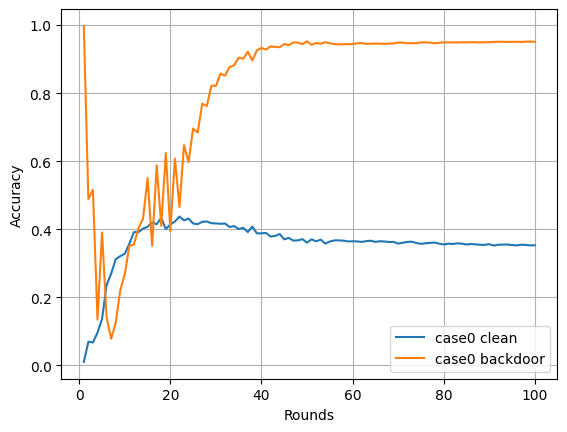

In [19]:
# from result_sample.usage import load_gen  # 或把 load_gen 那个 cell 里的函数复制过来

folder = "without_onboarding/"  # 或 with_onboarding，根据你文件放的位置
path = "cifar100_C5_BS128_R100_UR10_PR30_E1_LR0.01.pkl"  # 和前面用的一致

baseline = load_gen(folder + f"case0_{path}")
num_rounds = len(baseline["clean"])
rounds = list(range(1, num_rounds + 1))

plt.plot(rounds, baseline["clean"], label="case0 clean")
plt.plot(rounds, baseline["backdoor"], label="case0 backdoor")
plt.xlabel("Rounds"); plt.ylabel("Accuracy"); plt.grid(); plt.legend()
plt.show()

In [15]:
def show_last_round_result_before_onboarding(path, methods=[1, 2, 3, 4]):
    filename_baseline = f"case0_{path}"
    baseline = load_gen(folder + filename_baseline)

    clean_data = []
    backdoor_data = []

    clean_labels = []
    backdoor_labels = []

    method_names = [name[f"case{i}"] for i in methods]
    x_axis = np.arange(len(method_names))

    for i in methods:
        filename = f"case{i}_{path}"
        try:
            data = load_gen(folder + filename)
        except:
            continue
        case = f"case{i}"


        clean_data.append(data["clean"][-configs[configs["dataset"]]["num_post_training_round"]-1])
        backdoor_data.append(data["backdoor"][-configs[configs["dataset"]]["num_post_training_round"]-1])

        clean_label = f"{name[case]} clean"
        backdoor_label = f"{name[case]} backdoor"
        clean_labels.append(clean_label)
        backdoor_labels.append(backdoor_label)

    plt.bar(x_axis-0.2, clean_data, 0.4, label="clean")
    plt.bar(x_axis+0.2, backdoor_data, 0.4, label="backdoor")

    plt.xticks(x_axis, method_names)
    plt.xlabel('Methods')
    plt.ylabel('Accuracy')
    plt.title("Last Round Accuracy")
    plt.grid()
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    
    plt.show()

In [ ]:

# show_last_round_result_before_onboarding uses cfg dict now
# (kept for reference; main plots are in the cell above)
pass


In [ ]:
def show_numerical_result(path, methods=[1, 2, 3, 4], dataset = "mnist"):
    filename_baseline = f"case0_{path}"
    baseline = load_gen(folder + filename_baseline)

    clean_data = []
    backdoor_data = []

    clean_labels = []
    backdoor_labels = []

    # method_names = [name[f"case{i}"] for i in methods]
    # x_axis = np.arange(len(method_names))

    for i in methods:
        filename = f"case{i}_{path}"
        try:
            data = load_gen(folder + filename)
        except:
            continue

        case = f"case{i}"

        # clean_data.append(data["clean"][-1])
        # backdoor_data.append(data["backdoor"][-1])

        clean_label = f"{name[case]} clean"
        # clean_labels.append(clean_label)
        # backdoor_labels.append(backdoor_label)

        print(clean_label)
        
        res_str = ""

        if i == 1:
            # i=1: Continue train
            res_str += f"{data['clean'][configs[dataset]['num_round'] - 1]} & {data['backdoor'][configs[dataset]['num_round'] - 1]} & "
            res_str += f"{data['clean'][configs[dataset]['num_round']]} & {data['backdoor'][configs[dataset]['num_round']]} & "
            res_str += f"{data['clean'][configs[dataset]['num_round'] + configs[dataset]['num_unlearn_round'] - 1]} & {data['backdoor'][configs[dataset]['num_round'] + configs[dataset]['num_unlearn_round'] - 1]} & "
            res_str += f"{data['clean'][configs[dataset]['num_round'] + configs[dataset]['num_unlearn_round']]} & {data['backdoor'][configs[dataset]['num_round'] + configs[dataset]['num_unlearn_round']]} & "
            res_str += f"{data['clean'][configs[dataset]['num_round'] + configs[dataset]['num_unlearn_round'] + configs[dataset]['num_post_training_round'] - 1]} & {data['backdoor'][configs[dataset]['num_round'] + configs[dataset]['num_unlearn_round'] + configs[dataset]['num_post_training_round'] - 1]} & "
            res_str += f"{data['clean'][configs[dataset]['num_round'] + configs[dataset]['num_unlearn_round'] + configs[dataset]['num_post_training_round']]} & {data['backdoor'][configs[dataset]['num_round'] + configs[dataset]['num_unlearn_round'] + configs[dataset]['num_post_training_round']]} & "
            res_str += f"{data['clean'][-1]} & {data['backdoor'][-1]}"
        else:
            res_str += f"{baseline['clean'][configs[dataset]['num_round'] - 1]} & {baseline['backdoor'][configs[dataset]['num_round'] - 1]} & "
            res_str += f"{data['clean'][0]} & {data['backdoor'][0]} & "
            res_str += f"{data['clean'][configs[dataset]['num_unlearn_round'] - 1]} & {data['backdoor'][configs[dataset]['num_unlearn_round'] - 1]} & "
            res_str += f"{data['clean'][configs[dataset]['num_unlearn_round']]} & {data['backdoor'][configs[dataset]['num_unlearn_round']]} & "
            res_str += f"{data['clean'][configs[dataset]['num_unlearn_round'] + configs[dataset]['num_post_training_round'] - 1]} & {data['backdoor'][configs[dataset]['num_unlearn_round'] + configs[dataset]['num_post_training_round'] - 1]} & "
            res_str += f"{data['clean'][configs[dataset]['num_unlearn_round'] + configs[dataset]['num_post_training_round']]} & {data['backdoor'][configs[dataset]['num_unlearn_round'] + configs[dataset]['num_post_training_round']]} & "
            res_str += f"{data['clean'][-1]} & {data['backdoor'][-1]}"


        print(res_str)
        

In [ ]:
pass  # numerical result (legacy cell, superseded by results_summary.txt)

In [ ]:
def load_time(filename, type="acc"):
    with open(filename, 'rb') as fp:
        data = pickle.load(fp)["time"]
        return data



def show_time(path, methods):
    num_rounds = 0
    for i in [3, 4, 5]:
        temp = 0
        if i == 3:
            temp = int(path.split("_")[i][1:])
        else:
            temp = int(path.split("_")[i][2:])
        num_rounds += temp

    num_rounds += num_onboarding_rounds

    fl_rounds = [i for i in range(1, num_rounds + 1)]

    method_names = [name[f"case{i}"] for i in methods]
    x_axis = np.arange(len(method_names))

    retrain_time = 0
    factors = []

    for i in methods:
        filename = f"case{i}_{path}"
        try:
            time = load_time(folder + filename)
        except:
            print(filename)
            continue

        if i == 1:
            retrain_time = time

        factor = time/retrain_time

        factors.append(factor)

    # print(method_names)
    # print(factors)
    plt.bar(method_names, factors)
    plt.ylabel('Unit')
    plt.grid()
    #plt.locator_params(axis="x", integer=True)
    #plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

In [ ]:
pass  # time plot (legacy cell)

In [ ]:
def show_time_detail(path, methods):
    num_rounds = 0
    for i in [3, 4, 5]:
        temp = 0
        if i == 3:
            temp = int(path.split("_")[i][1:])
        else:
            temp = int(path.split("_")[i][2:])
        num_rounds += temp

    num_rounds += num_onboarding_rounds

    fl_rounds = [i for i in range(1, num_rounds + 1)]

    method_names = [name[f"case{i}"] for i in methods]
    x_axis = np.arange(len(method_names))

    retrain_time = 0
    factors = []

    for i in methods:
        filename = f"case{i}_{path}"
        try:
            time = load_time(folder + filename)
        except:
            print(filename)
            continue

        if i == 1:
            retrain_time = time

        factor = time/retrain_time

        factors.append(factor)

        print(f"{method_names[i-1]}: {time:.2f}({(retrain_time / time):.2f}x)")


In [ ]:
pass  # time detail (legacy cell)

In [ ]:
pass  # args dict (legacy cell, requires old configs structure)

In [ ]:
def load_model(path):
    model = get_model(args, plotting=True)
    model.load_state_dict(torch.load(path))

    return model

In [ ]:
pass  # model loading (requires .pt files, skip)

In [ ]:
def plot_diff(X, Y, title):
    Y = [y.cpu().numpy() for y in Y]
    
    plt.plot(X, Y)

    plt.xlabel('Rounds')
    plt.ylabel('Difference')

    plt.xticks(np.arange(min(X), max(X)+1, len(X) // 10))
    
    plt.title(title)
    
    plt.show()

In [ ]:
def compare_prediction(model1, model2, data_loader):
    model1.eval()
    model2.eval()

    output1s = torch.tensor([])
    output2s = torch.tensor([])

    with torch.no_grad():
        for data, target in data_loader:
            data = data.to(args["device"])
            target = target.to(args["device"])

            output1 = model1(data).argmax(dim=1).detach().cpu().float()
            output2 = model2(data).argmax(dim=1).detach().cpu().float()

            output1s = torch.cat((output1s, output1))
            output2s = torch.cat((output2s, output2))
    
    
    cos = torch.nn.CosineSimilarity(dim=0, eps=1e-9)
    return cos(output1s, output2s)



In [ ]:
pass  # cosine similarity (requires .pt files, skip)